In [1]:
# as bibliotecas e os importes que irei usar
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt

tf.random.set_seed(1)
print("GPUs disponíveis: ", len(tf.config.list_physical_devices('GPU')))

GPUs disponíveis:  1


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data() # carrega os codigos numericos

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
dataset = np.concatenate([x_train, x_test], axis=0) # une treino e teste
dataset = np.expand_dims(dataset, -1).astype("float32") / 255 # normaliza os dados

In [4]:
BATCH_SIZE = 64

dataset = np.reshape(dataset, (-1, 28, 28, 1)) # formata para as camadas
dataset = tf.data.Dataset.from_tensor_slices(dataset) # converte para objeto
dataset = dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE) # embaralha e agrupa em lotes

In [5]:
NOISE_DIM = 150 # dimensao

# recebe e aprende a gerar codigos
generator = keras.models.Sequential([
  keras.layers.InputLayer(input_shape=(NOISE_DIM,)),
  layers.Dense(7*7*256),
  layers.Reshape(target_shape=(7, 7, 256)),
  layers.Conv2DTranspose(256, 3, strides=2, padding="same"),
  layers.LeakyReLU(),
  layers.Conv2DTranspose(128, 3, strides=2, padding="same"),
  layers.LeakyReLU(),
  layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")
])

generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,894,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,153 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,780,417 (10.61 MB)

 Trainable params: 2,780,417 (10.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# taxas diferentes para falsificador e detector
optimizerG = keras.optimizers.Adam(learning_rate=0.00001, beta_1=0.5)
optimizerD = keras.optimizers.Adam(learning_rate=0.00003, beta_1=0.5)

lossFn = keras.losses.BinaryCrossentropy(from_logits=True) # real ou falsificado
gAccMetric = tf.keras.metrics.BinaryAccuracy() # acuracia do falsificador
dAccMetric = tf.keras.metrics.BinaryAccuracy() # acuracia do detector

In [7]:
@tf.function
def trainDStep(data):
  batchSize = tf.shape(data)[0]
  noise = tf.random.normal(shape=(batchSize, NOISE_DIM)) # ruido alimenta o falsificador

  # codigos reais recebem rotulo
  y_true = tf.concat([tf.ones(batchSize, 1), tf.zeros(batchSize, 1)], axis=0)

  with tf.GradientTape() as tape:
    fake = generator(noise) # falsificador gera codigos falsos
    x = tf.concat([data, fake], axis=0) # detector analisa reais e falsos juntos
    y_pred = discriminator(x)
    discriminatorLoss = lossFn(y_true, y_pred)

  grads = tape.gradient(discriminatorLoss, discriminator.trainable_weights)
  optimizerD.apply_gradients(zip(grads, discriminator.trainable_weights))
  dAccMetric.update_state(y_true, y_pred)

  return {"discriminator_loss": discriminatorLoss, "discriminator_accuracy": dAccMetric.result()}

In [8]:
@tf.function
def trainGStep(data):
  batchSize = tf.shape(data)[0]
  noise = tf.random.normal(shape=(batchSize, NOISE_DIM))
  y_true = tf.ones(batchSize, 1) # falsificador quer ser classificado como real

  with tf.GradientTape() as tape:
    y_pred = discriminator(generator(noise))
    generatorLoss = lossFn(y_true, y_pred) # perda baseada em quantas vezes foi pego

  grads = tape.gradient(generatorLoss, generator.trainable_weights)
  optimizerG.apply_gradients(zip(grads, generator.trainable_weights))
  gAccMetric.update_state(y_true, y_pred)

  return {"generator_loss": generatorLoss, "generator_accuracy": gAccMetric.result()}

In [9]:
# o detector que identifica falsificacoes
discriminator = keras.models.Sequential([
  keras.layers.InputLayer(input_shape=(28, 28, 1)),
  layers.Conv2D(64, 3, strides=2, padding="same"),
  layers.LeakyReLU(),
  layers.Conv2D(128, 3, strides=2, padding="same"),
  layers.LeakyReLU(),
  layers.Flatten(),
  layers.Dense(1, activation="sigmoid") # probabilidade de ser real
])

discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,769 (315.50 KB)

 Trainable params: 80,769 (315.50 KB)

 Non-trainable params: 0 (0.00 B)

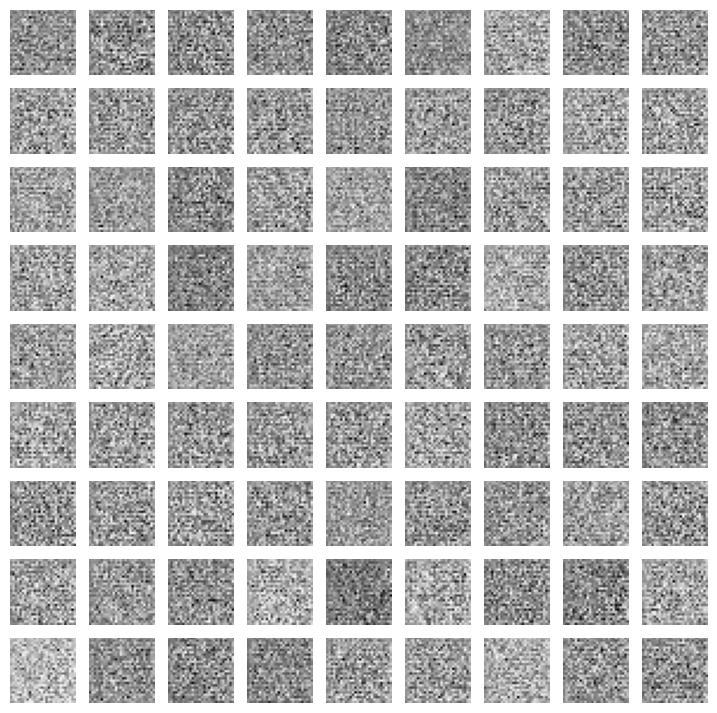

In [10]:
# gerar codigos imperiais falsificados com o modelo treinado
# se todas as imagens parecerem iguais ocorreu colapso de modo
images = generator(np.random.normal(size=(81, NOISE_DIM)))

plt.figure(figsize=(9, 9))
for i, image in enumerate(images):
  plt.subplot(9, 9, i+1)
  plt.imshow(np.squeeze(image, -1), cmap="Greys_r")
  plt.axis('off')
plt.show()